# Import

In [1]:
import os
import sys
import numpy as np
import pandas as pd

notebook_path = os.getcwd()
parent_path = os.path.abspath(os.path.join(notebook_path, '..'))

if parent_path not in sys.path:
    sys.path.append(parent_path)

from market_data import KalshiAnalyzer, KalshiClient, KalshiFeatureEngineer, KalshiResearch

# Test

In [2]:
rspl = KalshiResearch()

series_data = rspl.fetch_series()
series_tickers = list(series_data.ticker.unique())

In [ ]:
markets_data = rspl.fetch_markets_from_series(series_tickers[:100])

Extracting Markets: 100%|██████████| 10/10 [00:04<00:00,  2.29it/s]


In [4]:
tickers = list(markets_data.ticker.unique())
all_data = rspl.fetch_data(tickers)

Fetching: 100%|██████████| 121/121 [00:51<00:00,  2.37it/s]


In [5]:
def my_custom_features(df):
    f = pd.DataFrame(index=df.index)
    g = df.groupby(level=1)
    f['ret'] = g['close'].pct_change()
    f['vol'] = (df['high'] - df['low']) / df['open']
    f['mom_5'] = g['close'].transform(lambda x: x / x.shift(5) - 1) # Momentum 5 jours
    return f

X, y = rspl.prepare_ml_ready(my_custom_features)

Executing custom feature engineering...


In [6]:
import lightgbm as lgbm

model = lgbm.LGBMRegressor(n_estimators=100, learning_rate=0.05, verbosity=-1)
bt = rspl.run_backtest(model)

Backtesting: 100%|██████████| 143/143 [00:08<00:00, 16.78it/s]


<Axes: xlabel='ts'>

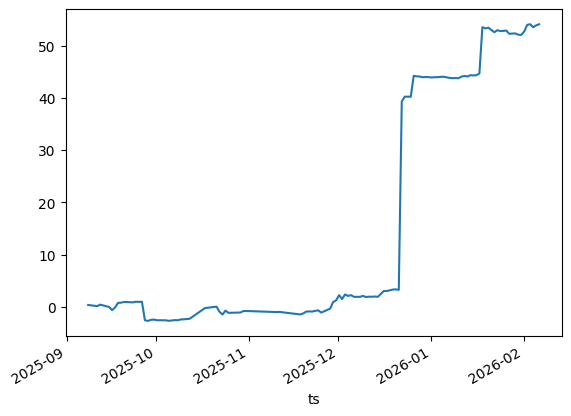

In [9]:
bt["pnl"].cumsum().plot()